# Backtesting H+F — Tous modèles
**France Hommes & Femmes 1950–2024 | PFA INSEA**

Ce notebook boucle automatiquement sur Male/Female et stocke tous les résultats
dans un dictionnaire `results[sex][model]` pour comparaison finale.

---
| Section | Contenu |
|---|---|
| 1 | Imports & données |
| 2 | Boucle H+F — tous modèles |
| 3 | Tableau comparatif final |
| 4 | Plots backtests H+F |
| 5 | Analyse de l'écart H/F |

## 1. Imports & données

In [2]:
import os, sys

# Chemin absolu vers la racine du projet
PROJECT_ROOT = r"C:\Users\PC-HP\Desktop\insea\Mortality Project"
# ex : r"C:\Users\PC-HP\Downloads\pfa_insea"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Root : {PROJECT_ROOT}")
print(f"src trouvé : {os.path.exists(os.path.join(PROJECT_ROOT, 'src'))}")

Root : C:\Users\PC-HP\Desktop\insea\Mortality Project
src trouvé : True


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

from src.models.lee_carter           import fit_lee_carter
from src.models.life_expectancy      import compute_life_table
from src.models.cbd_model            import fit_cbd
from src.models.uncertainty          import bootstrap_e0_ci
from src.models.forecast_evaluation  import rolling_backtest, compute_residual_std
from src.models.renshaw_haberman     import fit_renshaw_haberman, rolling_backtest_rh
from src.models.kalman_filter        import fit_kalman, rolling_backtest_bayesian
from src.models.pricing              import compute_annuity, annual_premium, price_all_models, annuity_var_cbd

os.makedirs('outputs', exist_ok=True)
print('Imports OK')

Imports OK


In [4]:
def load_data(project_root=PROJECT_ROOT):
    data_dir = os.path.join(project_root, 'data')
    df_d = pd.read_csv(os.path.join(data_dir, 'france_deaths_clean.csv'))
    df_p = pd.read_csv(os.path.join(data_dir, 'france_population_clean.csv'))
    d_l  = df_d.melt(id_vars=['Year','Age'], value_vars=['Male','Female'],
                     var_name='Sex', value_name='Deaths')
    p_l  = df_p.melt(id_vars=['Year','Age'], value_vars=['Male','Female'],
                     var_name='Sex', value_name='Population')
    df   = pd.merge(d_l, p_l, on=['Year','Age','Sex'])
    df['mx'] = df['Deaths'] / df['Population']
    return df[(df['Year'] >= 1950) & (df['Age'] <= 90) & (df['mx'] > 0)].copy()

df_all = load_data()

SEXES  = ['Female', 'Male']
LABELS = {'Female': 'Femmes', 'Male': 'Hommes'}
COLORS = {'Female': '#c04828', 'Male': '#185fa5'}

for sex in SEXES:
    df_tr = df_all[(df_all['Year']<=2000)&(df_all['Sex']==sex)]
    df_te = df_all[(df_all['Year']>2000) &(df_all['Sex']==sex)]
    print(f"{LABELS[sex]:8s} — Train {df_tr['Year'].min()}–{df_tr['Year'].max()}"
          f" ({df_tr['Age'].nunique()} âges) | "
          f"Test {df_te['Year'].min()}–{df_te['Year'].max()}"
          f" ({df_te['Year'].nunique()} années)")

Femmes   — Train 1950–2000 (91 âges) | Test 2001–2023 (23 années)
Hommes   — Train 1950–2000 (91 âges) | Test 2001–2023 (23 années)


## 2. Boucle H+F — tous modèles

In [6]:
# ── Optimisations clés ────────────────────────────────────────────────────────
# 1. ARIMA order fixé après le 1er fit (pas de model selection à chaque année)
# 2. n_boot 200→80, n_mc 600→300
# 3. Progress bar par année

from statsmodels.tsa.arima.model import ARIMA as StatsARIMA

def fast_arima_forecast(series_values, order, n_periods=1):
    """Forecast rapide avec ordre ARIMA fixé — évite auto_arima à chaque step."""
    try:
        m = StatsARIMA(series_values, order=order).fit(disp=False)
        fc = m.forecast(steps=n_periods)
        se = m.forecast(steps=n_periods, alpha=0.05)
        # Std depuis variance résiduelle
        std = float(np.sqrt(m.params.get('sigma2', m.resid.var())))
        return float(fc.iloc[-1]), std
    except:
        # Fallback : drift simple
        drift = float(np.mean(np.diff(series_values)))
        return float(series_values[-1]) + drift, float(np.std(np.diff(series_values)))

def get_arima_order(series_values):
    """Fit auto_arima une seule fois pour obtenir l'ordre optimal."""
    m = pm.auto_arima(series_values, seasonal=False, stepwise=True,
                      suppress_warnings=True, error_action='ignore')
    return m.order

results   = {sex: {} for sex in SEXES}
rh_params_all  = {}
kf_fit_all     = {}
lc_params_all  = {}
cbd_params_all = {}

t0_total = time.time()

for sex in SEXES:
    label = LABELS[sex]
    print(f'\n{"═"*55}')
    print(f'  {label.upper()}')
    print(f'{"═"*55}')

    df_tr = df_all[(df_all['Year']<=2000)&(df_all['Sex']==sex)].copy()
    df_te = df_all[(df_all['Year']>2000) &(df_all['Sex']==sex)].copy()
    years_test = sorted(df_te['Year'].unique())

    # ── Lee-Carter ────────────────────────────────────────────────────────────
    print(f'\n  [{label}] Lee-Carter...')
    t0 = time.time()
    ax, bx, kt = fit_lee_carter(df_tr)
    lc_params_all[sex] = (ax, bx, kt)
    res_lc = rolling_backtest(ax, bx, kt, df_tr, df_te, n_boot=100)
    results[sex]['Lee-Carter'] = res_lc
    print(f'  ✅ RMSE={res_lc["rmse"]:.4f}  Bias={res_lc["bias"]:+.4f}  '
          f'Coverage={res_lc["coverage"]:.1%}  ({time.time()-t0:.0f}s)')

    # ── CBD ───────────────────────────────────────────────────────────────────
    print(f'\n  [{label}] CBD...')
    t0 = time.time()

    k1_tr, k2_tr, xbar = fit_cbd(df_tr, age_min=50, age_max=85)
    df_cbd_tr = df_tr[(df_tr['Age']>=50)&(df_tr['Age']<=85)].copy()
    df_cbd_tr['qx'] = (df_cbd_tr['mx']/(1+0.5*df_cbd_tr['mx'])).clip(1e-6,1-1e-6)
    df_cbd_tr['logit_qx'] = np.log(df_cbd_tr['qx']/(1-df_cbd_tr['qx']))
    piv_cbd  = df_cbd_tr.pivot(index='Age',columns='Year',values='logit_qx')
    ages_cbd = piv_cbd.index.values.astype(float)
    lfit_cbd = pd.DataFrame({y:k1_tr[y]+k2_tr[y]*(ages_cbd-xbar)
                              for y in k1_tr.index}, index=ages_cbd)
    cbd_res_std = float(np.std((lfit_cbd.values-piv_cbd.values).ravel()))
    cbd_params_all[sex] = (k1_tr, k2_tr, xbar, ages_cbd, cbd_res_std)

    # Fitter l'ordre ARIMA une seule fois
    print(f'    Détection ordre ARIMA k1/k2...', end=' ')
    order_k1 = get_arima_order(k1_tr.values)
    order_k2 = get_arima_order(k2_tr.values)
    print(f'k1={order_k1}  k2={order_k2}')

    def full_e0_cbd(k1v, k2v):
        lq   = k1v + k2v*(ages_cbd-xbar)
        qx_o = (np.exp(lq)/(1+np.exp(lq))).clip(1e-6,1-1e-6)
        mx_o = (qx_o/(1-0.5*qx_o)).clip(min=1e-10)
        return mx_o

    k1_all = k1_tr.copy(); k2_all = k2_tr.copy()
    e0_obs_c,e0_pred_c,e0_lo_c,e0_hi_c = [],[],[],[]

    for i, year in enumerate(years_test):
        print(f'    [{i+1}/{len(years_test)}] {year}...', end='\r')
        df_y  = df_te[df_te['Year']==year]
        df_yg = df_y[df_y['Age']<=49][['Age','mx']].reset_index(drop=True)
        df_yt = df_y[(df_y['Age']>=86)&(df_y['Age']<=90)][['Age','mx']].reset_index(drop=True)
        df_yo = df_y[(df_y['Age']>=50)&(df_y['Age']<=85)][['Age','mx']].reset_index(drop=True)
        df_ext= pd.concat([df_yg,df_yt],ignore_index=True)

        # Forecast k1/k2 avec ordre fixé
        k1p, k1s = fast_arima_forecast(k1_all.values, order_k1)
        k2p, k2s = fast_arima_forecast(k2_all.values, order_k2)

        df_obs = pd.concat([df_yg,df_yo,df_yt],ignore_index=True).sort_values('Age').reset_index(drop=True)
        e0_obs_c.append(compute_life_table(df_obs).iloc[0]['ex'])

        mx_pred = full_e0_cbd(k1p, k2p)
        df_full = pd.concat([df_ext,
                             pd.DataFrame({'Age':ages_cbd.astype(int),'mx':mx_pred})],
                            ignore_index=True).sort_values('Age').reset_index(drop=True)
        e0_pred_c.append(compute_life_table(df_full).iloc[0]['ex'])

        # Bootstrap vectorisé
        k1_s_arr = np.random.normal(k1p, k1s, size=80)
        k2_s_arr = np.random.normal(k2p, k2s, size=80)
        noise_arr = np.random.normal(0, cbd_res_std, size=(80, len(ages_cbd)))

        boot = []
        for j in range(80):
            mx_s = ((np.exp(k1_s_arr[j]+k2_s_arr[j]*(ages_cbd-xbar)+noise_arr[j]) /
                    (1+np.exp(k1_s_arr[j]+k2_s_arr[j]*(ages_cbd-xbar)+noise_arr[j]))).clip(1e-6,1-1e-6))
            mx_s = (mx_s/(1-0.5*mx_s)).clip(min=1e-10)
            df_s = pd.concat([df_ext,
                              pd.DataFrame({'Age':ages_cbd.astype(int),'mx':mx_s})],
                             ignore_index=True).sort_values('Age').reset_index(drop=True)
            boot.append(compute_life_table(df_s).iloc[0]['ex'])

        e0_lo_c.append(np.percentile(boot,2.5))
        e0_hi_c.append(np.percentile(boot,97.5))

        # Update k1/k2
        df_yr = df_te[(df_te['Year']==year)&(df_te['Age']>=50)&(df_te['Age']<=85)][['Age','mx']].reset_index(drop=True)
        qx_yr = (df_yr['mx']/(1+0.5*df_yr['mx'])).clip(1e-6,1-1e-6)
        logit_yr = np.log(qx_yr/(1-qx_yr))
        X = np.column_stack([np.ones(len(ages_cbd)), ages_cbd-xbar])
        c = np.linalg.lstsq(X, logit_yr.values, rcond=None)[0]
        k1_all = pd.concat([k1_all, pd.Series([c[0]], index=[year])])
        k2_all = pd.concat([k2_all, pd.Series([c[1]], index=[year])])

    e0_obs_c=np.array(e0_obs_c); e0_pred_c=np.array(e0_pred_c)
    e0_lo_c=np.array(e0_lo_c);   e0_hi_c=np.array(e0_hi_c)
    rmse_c=float(np.sqrt(np.mean((e0_pred_c-e0_obs_c)**2)))
    bias_c=float(np.mean(e0_pred_c-e0_obs_c))
    cov_c =float(np.mean((e0_obs_c>=e0_lo_c)&(e0_obs_c<=e0_hi_c)))
    results[sex]['CBD'] = {'years':years_test,'e0_obs':e0_obs_c,'e0_pred':e0_pred_c,
                           'e0_lower':e0_lo_c,'e0_upper':e0_hi_c,
                           'rmse':rmse_c,'bias':bias_c,'coverage':cov_c}
    print(f'\n  ✅ RMSE={rmse_c:.4f}  Bias={bias_c:+.4f}  '
          f'Coverage={cov_c:.1%}  ({time.time()-t0:.0f}s)')

    # ── Renshaw-Haberman ──────────────────────────────────────────────────────
    print(f'\n  [{label}] Renshaw-Haberman...')
    t0 = time.time()
    rh_p = fit_renshaw_haberman(df_tr)
    rh_params_all[sex] = rh_p

    # Fixer ordre ARIMA kt RH
    order_kt_rh = get_arima_order(rh_p['kt'].values)
    print(f'    Ordre ARIMA kt RH : {order_kt_rh}')

    # Version rapide rolling_backtest_rh avec ordre fixé
    from src.models.renshaw_haberman import get_gamma, predict_rh
    from src.models.life_expectancy  import compute_life_table

    kt_all_rh    = rh_p['kt'].copy()
    ax_rh        = rh_p['ax']; bx_rh = rh_p['bx']
    gamma_c      = rh_p['gamma_c']
    ages_arr     = rh_p['ages_arr']
    A            = len(ages_arr)
    residual_rh  = rh_p['residual_std']
    gamma_series = pd.Series(gamma_c).sort_index()
    e0_obs_rh,e0_pred_rh,e0_lo_rh,e0_hi_rh = [],[],[],[]

    for i, year in enumerate(years_test):
        print(f'    [{i+1}/{len(years_test)}] {year}...', end='\r')
        df_yr_obs = df_te[(df_te['Year']==year)&(df_te['Age']<=90)][['Age','mx']].sort_values('Age').reset_index(drop=True)
        e0_obs_rh.append(compute_life_table(df_yr_obs).iloc[0]['ex'])

        kt_pt, kt_std = fast_arima_forecast(kt_all_rh.values, order_kt_rh)

        log_pred = np.array([ax_rh[ai]+bx_rh[ai]*kt_pt+
                              get_gamma(year-ages_arr[ai],gamma_c,gamma_series)
                              for ai in range(A)])
        e0_pred_rh.append(compute_life_table(
            pd.DataFrame({'Age':ages_arr.astype(int),'mx':np.exp(log_pred).clip(min=1e-10)})
        ).iloc[0]['ex'])

        kt_s_arr = np.random.normal(kt_pt, kt_std, size=80)
        ns_arr   = np.random.normal(0, residual_rh, size=(80,A))
        boot = []
        for j in range(80):
            log_s = np.array([ax_rh[ai]+bx_rh[ai]*kt_s_arr[j]+
                              get_gamma(year-ages_arr[ai],gamma_c,gamma_series)+ns_arr[j,ai]
                              for ai in range(A)])
            boot.append(compute_life_table(
                pd.DataFrame({'Age':ages_arr.astype(int),'mx':np.exp(log_s).clip(min=1e-10)})
            ).iloc[0]['ex'])

        e0_lo_rh.append(np.percentile(boot,2.5))
        e0_hi_rh.append(np.percentile(boot,97.5))

        log_obs = np.log(df_yr_obs['mx'].values.clip(min=1e-10))
        gamma_o = np.array([get_gamma(year-x,gamma_c,gamma_series) for x in ages_arr])
        kt_obs  = float(np.dot(bx_rh,log_obs-ax_rh-gamma_o)/np.dot(bx_rh,bx_rh))
        kt_all_rh = pd.concat([kt_all_rh, pd.Series([kt_obs],index=[year])])

    e0_obs_rh=np.array(e0_obs_rh); e0_pred_rh=np.array(e0_pred_rh)
    e0_lo_rh=np.array(e0_lo_rh);   e0_hi_rh=np.array(e0_hi_rh)
    rmse_rh=float(np.sqrt(np.mean((e0_pred_rh-e0_obs_rh)**2)))
    bias_rh=float(np.mean(e0_pred_rh-e0_obs_rh))
    cov_rh =float(np.mean((e0_obs_rh>=e0_lo_rh)&(e0_obs_rh<=e0_hi_rh)))
    results[sex]['Renshaw-Haberman'] = {'years':years_test,'e0_obs':e0_obs_rh,
        'e0_pred':e0_pred_rh,'e0_lower':e0_lo_rh,'e0_upper':e0_hi_rh,
        'rmse':rmse_rh,'bias':bias_rh,'coverage':cov_rh}
    rh_params_all[sex] = rh_p
    print(f'\n  ✅ RMSE={rmse_rh:.4f}  Bias={bias_rh:+.4f}  '
          f'Coverage={cov_rh:.1%}  ({time.time()-t0:.0f}s)')

    # ── LC Bayésien ───────────────────────────────────────────────────────────
    print(f'\n  [{label}] LC Bayésien (Kalman)...')
    t0 = time.time()
    kf = fit_kalman(ax, bx, kt, df_tr)
    kf_fit_all[sex] = kf
    res_bay = rolling_backtest_bayesian(ax, bx, kt, kf, df_te, n_mc=300)
    results[sex]['LC Bayésien'] = res_bay
    print(f'  ✅ RMSE={res_bay["rmse"]:.4f}  Bias={res_bay["bias"]:+.4f}  '
          f'Coverage={res_bay["coverage"]:.1%}  ({time.time()-t0:.0f}s)')

    print(f'\n  {label} ✅ — total {(time.time()-t0_total)/60:.1f} min')

print(f'\n{"═"*55}')
print(f'  TERMINÉ — {(time.time()-t0_total)/60:.1f} min total')
print(f'{"═"*55}')


═══════════════════════════════════════════════════════
  FEMMES
═══════════════════════════════════════════════════════

  [Femmes] Lee-Carter...
  ✅ RMSE=0.4628  Bias=+0.1473  Coverage=82.6%  (265s)

  [Femmes] CBD...
    Détection ordre ARIMA k1/k2... k1=(0, 1, 1)  k2=(0, 2, 2)
    [23/23] 2023...
  ✅ RMSE=0.1880  Bias=+0.0838  Coverage=91.3%  (90s)

  [Femmes] Renshaw-Haberman...
    Ordre ARIMA kt RH : (2, 1, 2)
    [23/23] 2023...
  ✅ RMSE=0.3842  Bias=+0.0515  Coverage=87.0%  (77s)

  [Femmes] LC Bayésien (Kalman)...
  ✅ RMSE=0.4818  Bias=+0.1986  Coverage=95.7%  (269s)

  Femmes ✅ — total 11.7 min

═══════════════════════════════════════════════════════
  HOMMES
═══════════════════════════════════════════════════════

  [Hommes] Lee-Carter...
  ✅ RMSE=0.6363  Bias=-0.5515  Coverage=47.8%  (121s)

  [Hommes] CBD...
    Détection ordre ARIMA k1/k2... k1=(0, 1, 1)  k2=(1, 1, 0)
    [23/23] 2023...
  ✅ RMSE=0.2280  Bias=-0.0868  Coverage=95.7%  (73s)

  [Hommes] Renshaw-Haberman..

## 3. Tableau comparatif final H+F

In [7]:
MODELS = ['Lee-Carter','CBD','Renshaw-Haberman','LC Bayésien']

rows = []
for model in MODELS:
    row = {'Modèle': model}
    for sex in SEXES:
        r = results[sex][model]
        label = LABELS[sex]
        row[f'RMSE {label}']     = f"{r['rmse']:.4f}"
        row[f'Biais {label}']    = f"{r['bias']:+.4f}"
        row[f'Coverage {label}'] = f"{r['coverage']:.1%}"
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Modèle')
print('\n' + '═'*90)
print('  BILAN BACKTEST — France H+F | 2001–2020 | Rolling one-step-ahead')
print('═'*90)
print(df_summary.to_string())
print('═'*90)

# Sauvegarder
df_summary.to_csv('outputs/backtest_summary_HF.csv')
print('\n  Tableau sauvegardé → outputs/backtest_summary_HF.csv')


══════════════════════════════════════════════════════════════════════════════════════════
  BILAN BACKTEST — France H+F | 2001–2020 | Rolling one-step-ahead
══════════════════════════════════════════════════════════════════════════════════════════
                 RMSE Femmes Biais Femmes Coverage Femmes RMSE Hommes Biais Hommes Coverage Hommes
Modèle                                                                                            
Lee-Carter            0.4628      +0.1473           82.6%      0.6363      -0.5515           47.8%
CBD                   0.1880      +0.0838           91.3%      0.2280      -0.0868           95.7%
Renshaw-Haberman      0.3842      +0.0515           87.0%      0.5818      -0.4708           60.9%
LC Bayésien           0.4818      +0.1986           95.7%      0.6918      -0.6240           65.2%
══════════════════════════════════════════════════════════════════════════════════════════

  Tableau sauvegardé → outputs/backtest_summary_HF.csv


## 4. Plots backtests H+F

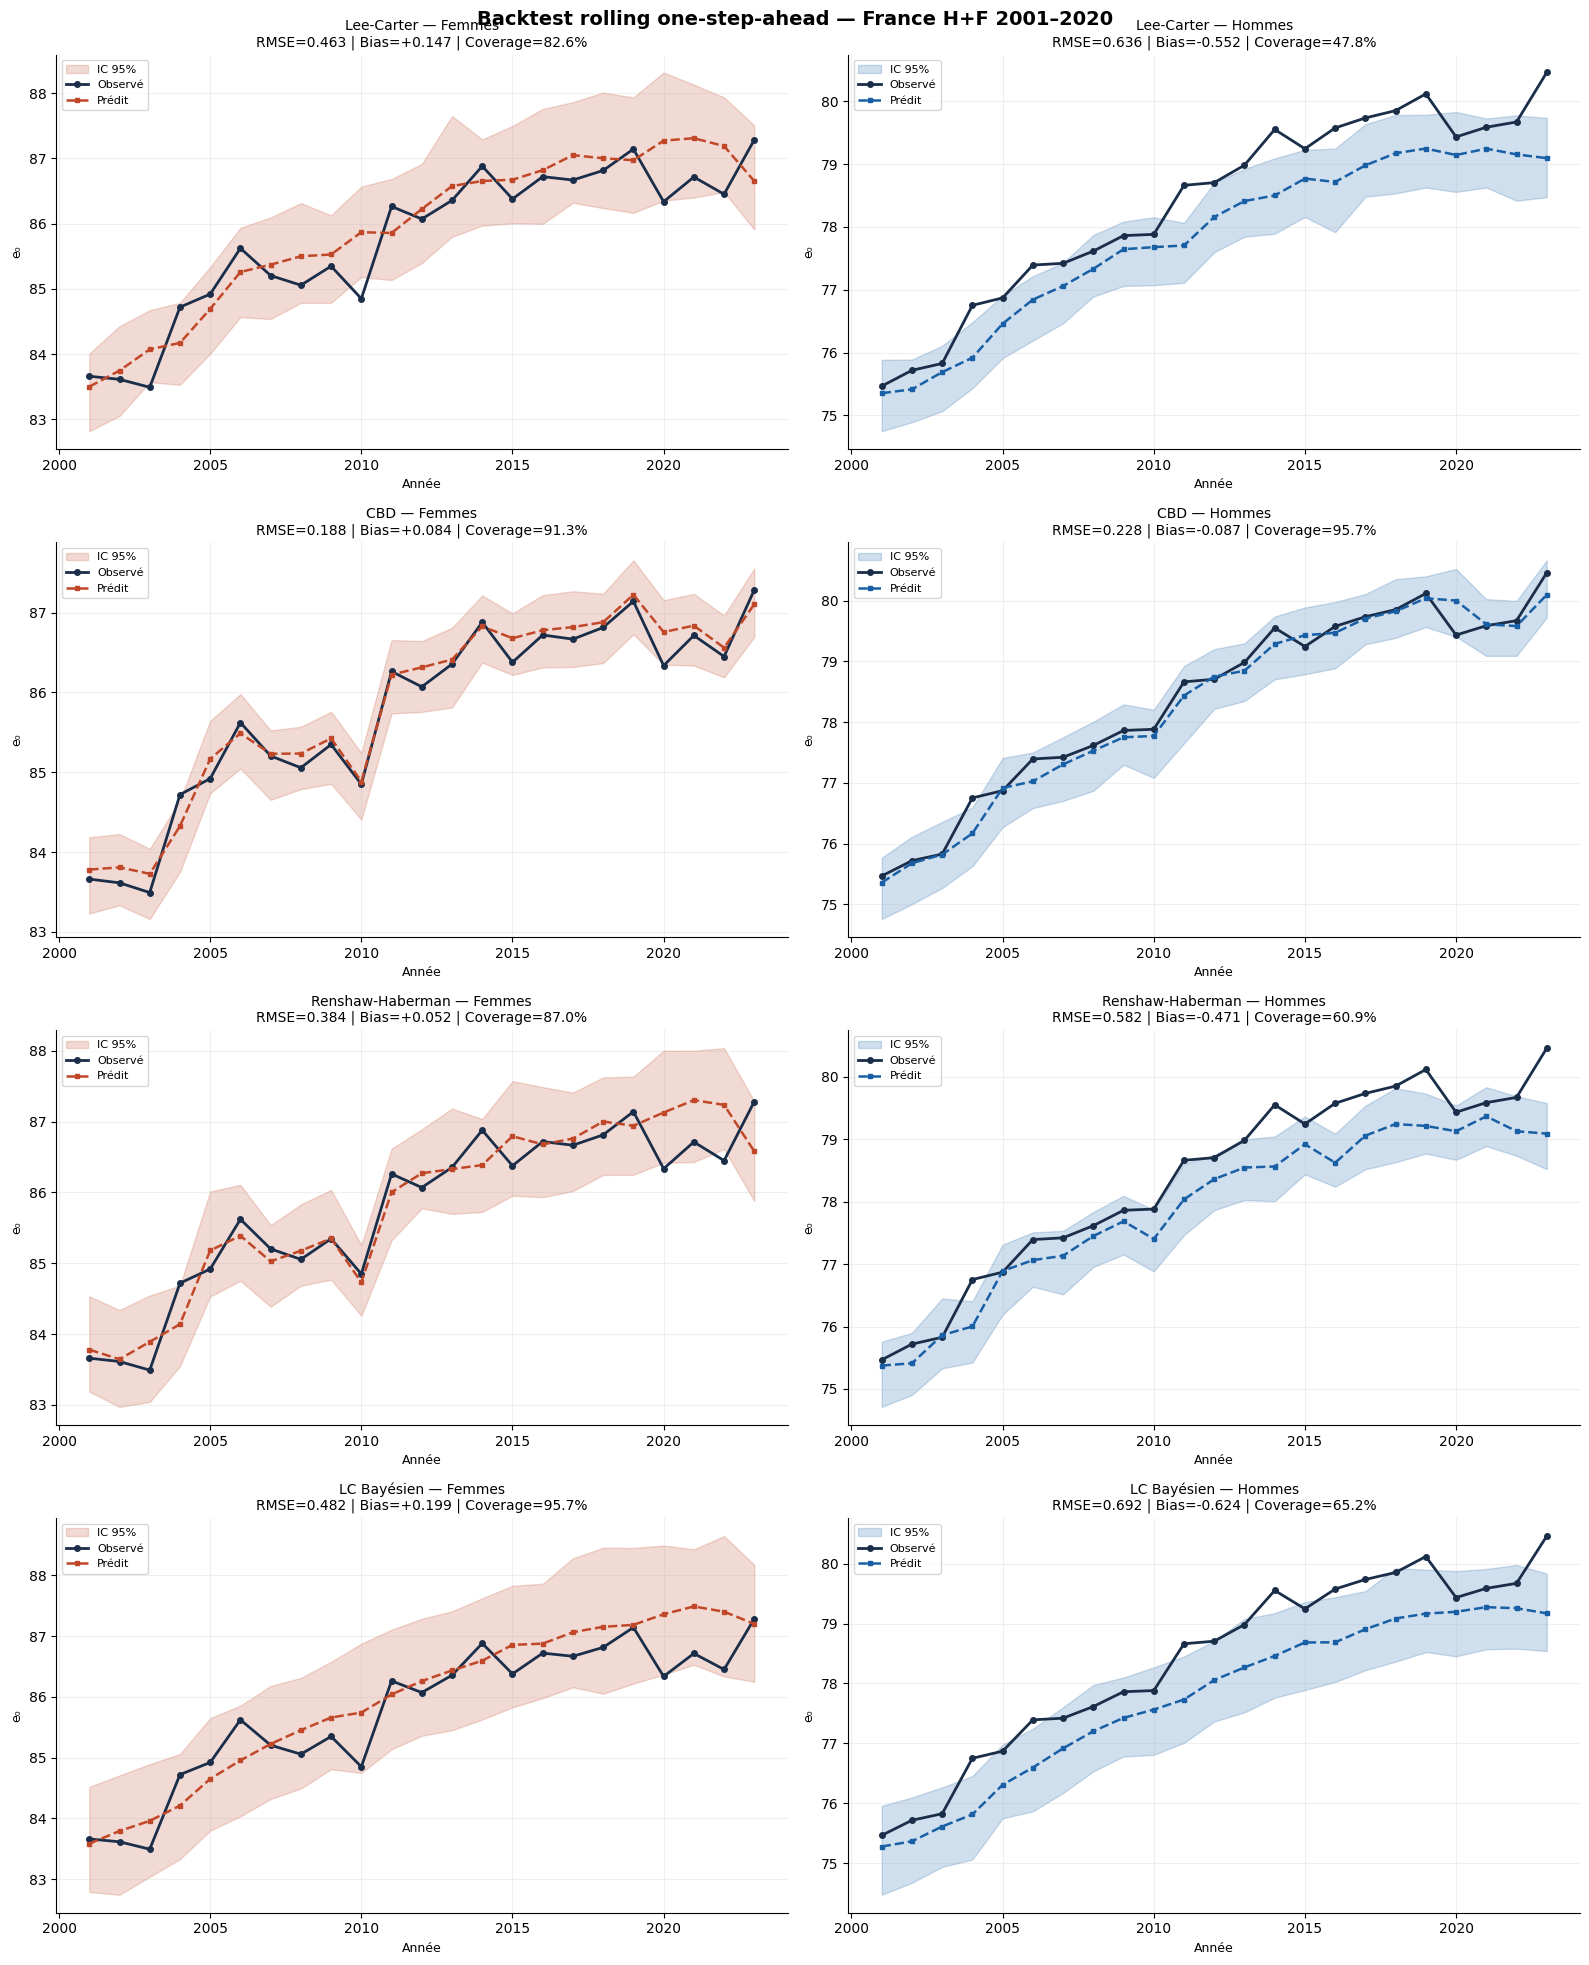

Plot sauvegardé → outputs/backtest_HF_all_models.png


In [8]:
# ── Plot 4x2 : 4 modèles × 2 sexes ──────────────────────────────────────────
fig, axes = plt.subplots(len(MODELS), 2, figsize=(16, 5*len(MODELS)), sharey=False)
fig.suptitle('Backtest rolling one-step-ahead — France H+F 2001–2020',
             fontsize=14, fontweight='bold')

for row_i, model in enumerate(MODELS):
    for col_i, sex in enumerate(SEXES):
        ax = axes[row_i][col_i]
        res = results[sex][model]
        color = COLORS[sex]

        ax.fill_between(res['years'], res['e0_lower'], res['e0_upper'],
                        alpha=0.2, color=color, label='IC 95%')
        ax.plot(res['years'], res['e0_obs'],  'o-', color='#1a2e4a',
                lw=2, markersize=4, label='Observé')
        ax.plot(res['years'], res['e0_pred'], 's--', color=color,
                lw=1.8, markersize=3, label='Prédit')

        ax.set_title(f'{model} — {LABELS[sex]}\n'
                     f'RMSE={res["rmse"]:.3f} | Bias={res["bias"]:+.3f} | '
                     f'Coverage={res["coverage"]:.1%}',
                     fontsize=10)
        ax.set_xlabel('Année', fontsize=9)
        ax.set_ylabel('e₀', fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.2)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/backtest_HF_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot sauvegardé → outputs/backtest_HF_all_models.png')

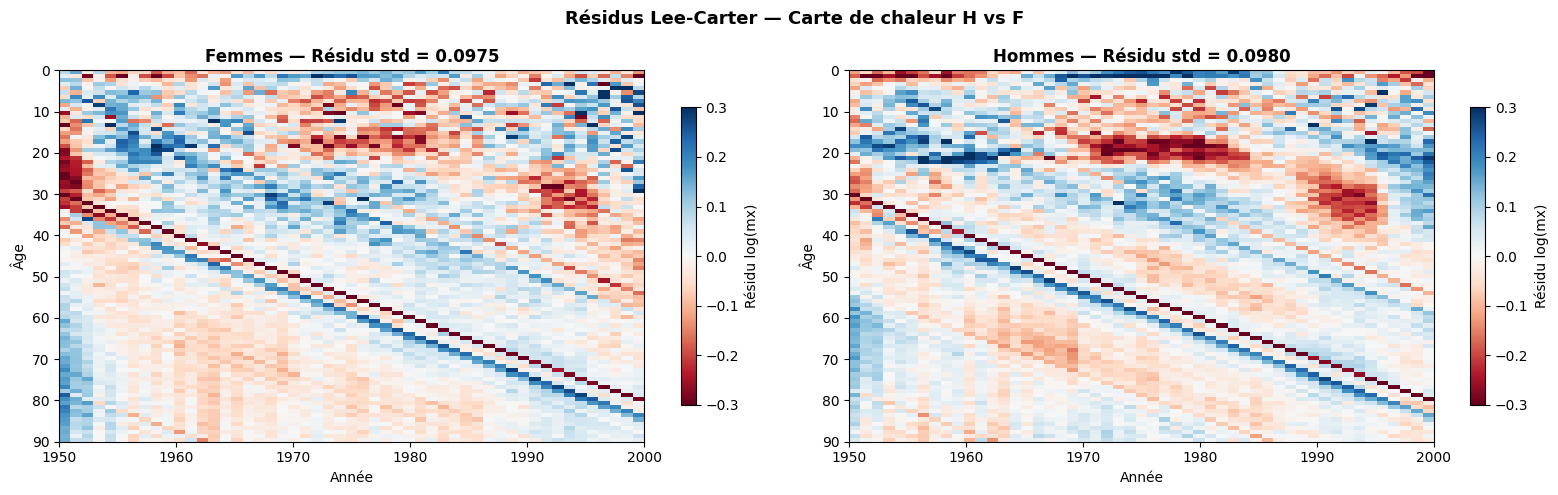

Plot sauvegardé → outputs/lc_residuals_HF.png


In [9]:
# ── Heatmaps résidus H+F côte-à-côte ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Résidus Lee-Carter — Carte de chaleur H vs F',
             fontsize=13, fontweight='bold')

for ax_i, sex in enumerate(SEXES):
    df_tr = df_all[(df_all['Year']<=2000)&(df_all['Sex']==sex)].copy()
    ax_lc, bx_lc, kt_lc = lc_params_all[sex]
    pivot = df_tr.pivot(index='Age', columns='Year', values='mx')
    log_obs = np.log(pivot.clip(lower=1e-10).values)
    log_fit = np.column_stack([ax_lc.values+bx_lc.values*kt_lc[y] for y in kt_lc.index])
    residuals = log_fit - log_obs

    a = axes[ax_i]
    im = a.imshow(residuals, aspect='auto', cmap='RdBu', vmin=-0.3, vmax=0.3,
                  extent=[kt_lc.index[0], kt_lc.index[-1], 90, 0])
    plt.colorbar(im, ax=a, label='Résidu log(mx)', shrink=0.8)
    a.set_xlabel('Année'); a.set_ylabel('Âge')
    resid_std = float(np.std(residuals.ravel()))
    a.set_title(f'{LABELS[sex]} — Résidu std = {resid_std:.4f}', fontweight='600')

plt.tight_layout()
plt.savefig('outputs/lc_residuals_HF.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot sauvegardé → outputs/lc_residuals_HF.png')

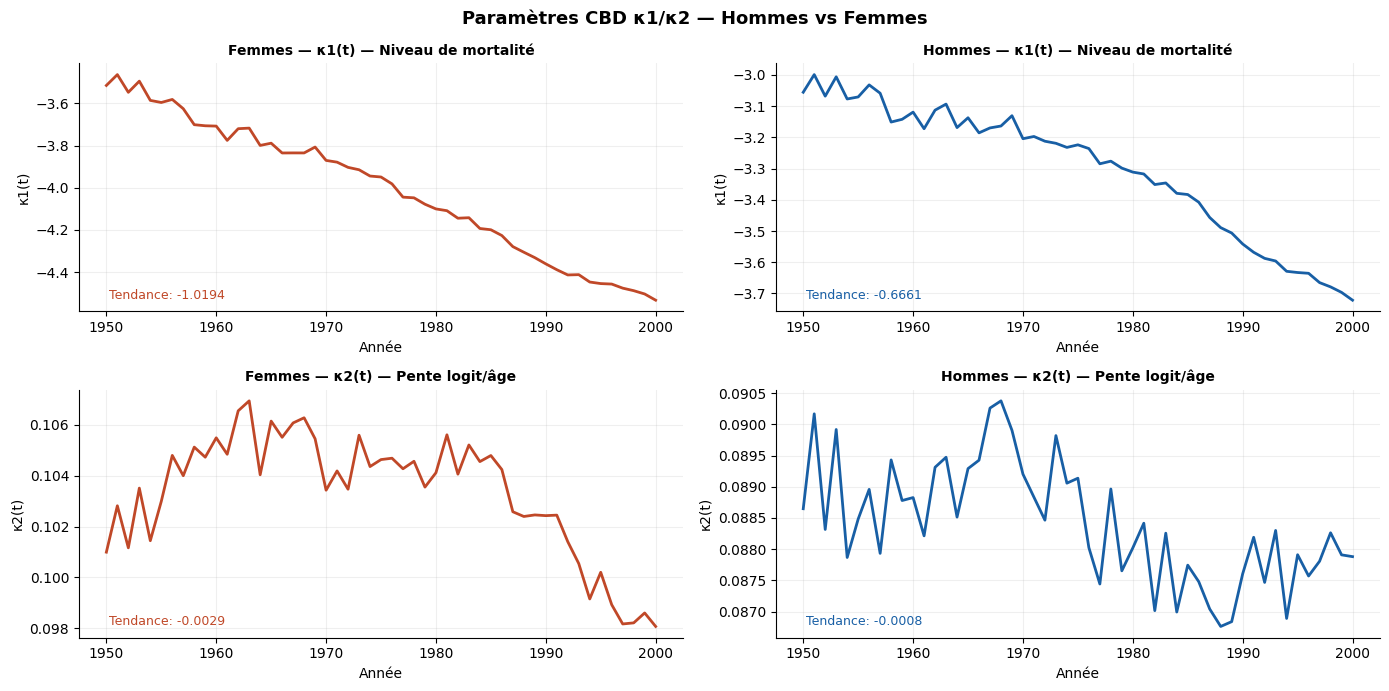

Plot sauvegardé → outputs/cbd_k1k2_HF.png


In [10]:
# ── CBD k1/k2 H+F ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Paramètres CBD κ1/κ2 — Hommes vs Femmes', fontsize=13, fontweight='bold')

param_labels = ['κ1(t) — Niveau de mortalité', 'κ2(t) — Pente logit/âge']

for col_i, sex in enumerate(SEXES):
    k1_tr, k2_tr, xbar, _, _ = cbd_params_all[sex]
    color = COLORS[sex]

    for row_i, (k, label) in enumerate(zip([k1_tr, k2_tr], param_labels)):
        a = axes[row_i][col_i]
        k.plot(ax=a, color=color, lw=2)
        a.set_title(f'{LABELS[sex]} — {label}', fontsize=10, fontweight='600')
        a.set_xlabel('Année')
        a.grid(alpha=0.2)
        a.spines[['top','right']].set_visible(False)
        trend = k.iloc[-1]-k.iloc[0]
        a.set_ylabel(label.split('—')[0].strip())
        a.text(0.05, 0.05, f'Tendance: {trend:+.4f}',
               transform=a.transAxes, fontsize=9, color=color)

plt.tight_layout()
plt.savefig('outputs/cbd_k1k2_HF.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot sauvegardé → outputs/cbd_k1k2_HF.png')

## 5. Analyse de l'écart H/F

=== Écart e0 Femmes - Hommes ===
  1950 : +5.81 ans
  1980 : +8.42 ans
  2000 : +8.14 ans
  2020 : +6.82 ans
  Tendance : Stable/Divergence


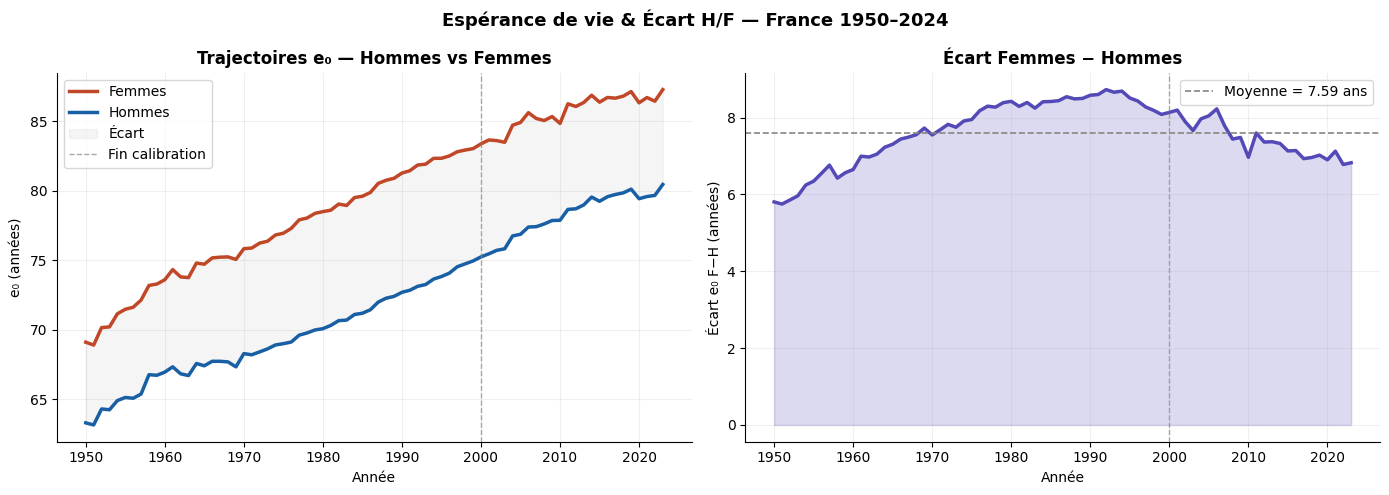

Plot sauvegardé → outputs/gender_gap_e0.png


In [11]:
# ── e0 observé H vs F sur toute la période ───────────────────────────────────
e0_series = {}
for sex in SEXES:
    e0_list = []
    for year in sorted(df_all['Year'].unique()):
        df_y = df_all[(df_all['Year']==year)&(df_all['Sex']==sex)][['Age','mx']].reset_index(drop=True)
        if len(df_y) > 0:
            try:
                lt = compute_life_table(df_y)
                e0_list.append({'Year':year,'e0':lt.iloc[0]['ex']})
            except:
                pass
    e0_series[sex] = pd.DataFrame(e0_list).set_index('Year')['e0']

gap = e0_series['Female'] - e0_series['Male']

print('=== Écart e0 Femmes - Hommes ===')
print(f'  1950 : {gap.iloc[0]:+.2f} ans')
print(f'  1980 : {gap.get(1980,float("nan")):+.2f} ans')
print(f'  2000 : {gap.get(2000,float("nan")):+.2f} ans')
print(f'  2020 : {gap.iloc[-1]:+.2f} ans')
print(f'  Tendance : {"Convergence" if gap.iloc[-1] < gap.iloc[0] else "Stable/Divergence"}')

# ── Plot écart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Espérance de vie & Écart H/F — France 1950–2024',
             fontsize=13, fontweight='bold')

# Trajectoires H+F
ax1 = axes[0]
for sex in SEXES:
    ax1.plot(e0_series[sex].index, e0_series[sex].values,
             lw=2.5, color=COLORS[sex], label=LABELS[sex])
ax1.fill_between(e0_series['Female'].index,
                 e0_series['Male'].reindex(e0_series['Female'].index),
                 e0_series['Female'].values, alpha=0.08, color='#888780',
                 label='Écart')
ax1.axvline(2000, color='#888780', ls='--', lw=1, alpha=0.7, label='Fin calibration')
ax1.set_xlabel('Année'); ax1.set_ylabel('e₀ (années)')
ax1.set_title('Trajectoires e₀ — Hommes vs Femmes', fontweight='600')
ax1.legend(fontsize=10); ax1.grid(alpha=0.2)
ax1.spines[['top','right']].set_visible(False)

# Écart
ax2 = axes[1]
ax2.fill_between(gap.index, gap.values, alpha=0.2, color='#534ab7')
ax2.plot(gap.index, gap.values, color='#534ab7', lw=2.5)
ax2.axhline(gap.mean(), color='#888780', ls='--', lw=1.2,
            label=f'Moyenne = {gap.mean():.2f} ans')
ax2.axvline(2000, color='#888780', ls='--', lw=1, alpha=0.7)
ax2.set_xlabel('Année'); ax2.set_ylabel('Écart e₀ F−H (années)')
ax2.set_title('Écart Femmes − Hommes', fontweight='600')
ax2.legend(fontsize=10); ax2.grid(alpha=0.2)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/gender_gap_e0.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot sauvegardé → outputs/gender_gap_e0.png')

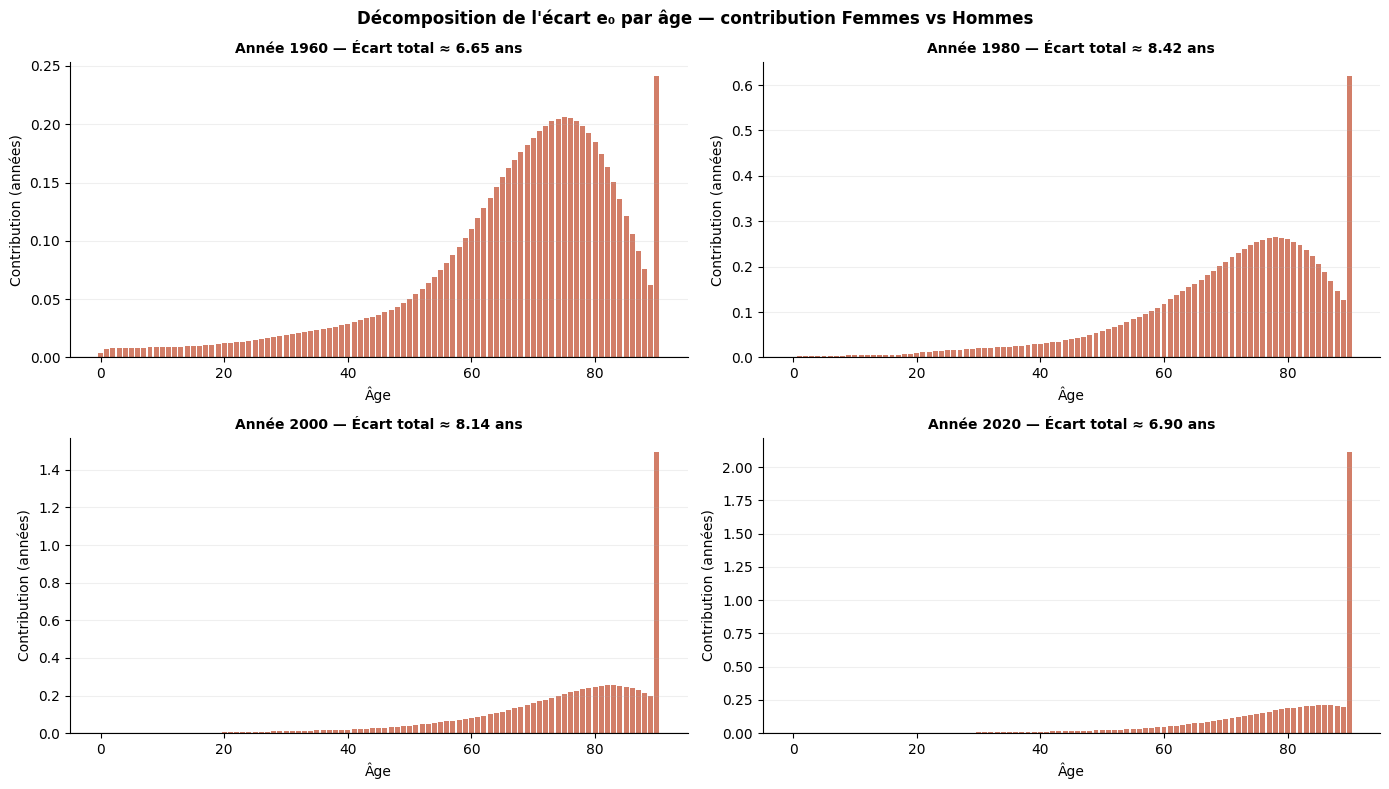

Plot sauvegardé → outputs/gender_gap_decomposition.png


In [12]:
# ── Décomposition de l'écart par âge ─────────────────────────────────────────
# Pour chaque année de référence, contribu. de chaque âge à l'écart e0
ref_years = [1960, 1980, 2000, 2020]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Décomposition de l\'écart e₀ par âge — contribution Femmes vs Hommes',
             fontsize=12, fontweight='bold')

for ax_i, year in enumerate(ref_years):
    row, col = divmod(ax_i, 2)
    a = axes[row][col]

    contrib = {}
    for sex in SEXES:
        df_y = df_all[(df_all['Year']==year)&(df_all['Sex']==sex)][['Age','mx']]
        if len(df_y) > 0:
            lt = compute_life_table(df_y.reset_index(drop=True))
            # contribution de l'âge x = lx/100000 * (ex_F - ex_M approximé par ex)
            contrib[sex] = lt.set_index('Age')['Lx'] / 100_000

    if 'Female' in contrib and 'Male' in contrib:
        ages_common = sorted(set(contrib['Female'].index) & set(contrib['Male'].index))
        diff = pd.Series({age: contrib['Female'].get(age,0) - contrib['Male'].get(age,0)
                          for age in ages_common})
        colors_bar = ['#c04828' if v>0 else '#185fa5' for v in diff.values]
        a.bar(diff.index, diff.values, color=colors_bar, alpha=0.7, width=0.8)
        a.axhline(0, color='black', lw=0.8)
        a.set_title(f'Année {year} — Écart total ≈ {gap.get(year,float("nan")):.2f} ans',
                    fontsize=10, fontweight='600')
        a.set_xlabel('Âge'); a.set_ylabel('Contribution (années)')
        a.grid(alpha=0.2, axis='y')
        a.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/gender_gap_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot sauvegardé → outputs/gender_gap_decomposition.png')

In [13]:
# ── Pricing comparatif H vs F ─────────────────────────────────────────────────
TAUX_TECH  = 0.02
CAPITAL    = 100_000
PROJ_YEAR  = 2025

print('═'*65)
print('  PRICING RENTE VIAGÈRE — Comparaison H vs F | 2025 | i=2%')
print('═'*65)

pricing_results = {}

for age_x in [60, 65, 70]:
    print(f'\n  Âge de souscription : {age_x} ans')
    print(f'  {"─"*60}')
    print(f'  {"Modèle":<25} {"Femme äx":>10} {"Femme Prime":>12} {"Homme äx":>10} {"Homme Prime":>12}')
    print(f'  {"─"*60}')

    for model in ['Lee-Carter','CBD']:
        ax_vals = {}
        for sex in SEXES:
            ax_lc_s, bx_lc_s, kt_lc_s = lc_params_all[sex]
            k1_s, k2_s, xbar_s, ages_cbd_s, _ = cbd_params_all[sex]
            n_fc = PROJ_YEAR - int(kt_lc_s.index[-1])

            m_kt = pm.auto_arima(kt_lc_s.values, seasonal=False, stepwise=True,
                                  suppress_warnings=True, error_action='ignore')
            kt_25 = float(m_kt.predict(n_periods=n_fc)[-1])
            mx_lc_25 = np.exp(ax_lc_s.values + bx_lc_s.values * kt_25).clip(min=1e-10)
            df_lc_25 = pd.DataFrame({'Age': ax_lc_s.index.tolist(), 'mx': mx_lc_25})

            if model == 'Lee-Carter':
                ax_val = compute_annuity(df_lc_25, age_x, TAUX_TECH)
            else:
                m1 = pm.auto_arima(k1_s.values, seasonal=False, stepwise=True,
                                    suppress_warnings=True, error_action='ignore')
                m2 = pm.auto_arima(k2_s.values, seasonal=False, stepwise=True,
                                    suppress_warnings=True, error_action='ignore')
                k1_25 = float(m1.predict(n_periods=n_fc)[-1])
                k2_25 = float(m2.predict(n_periods=n_fc)[-1])
                lq = k1_25 + k2_25*(ages_cbd_s - xbar_s)
                qx_c = (np.exp(lq)/(1+np.exp(lq))).clip(1e-6,1-1e-6)
                mx_c = (qx_c/(1-0.5*qx_c)).clip(min=1e-10)
                df_c = df_lc_25.copy()
                for i,age in enumerate(ages_cbd_s.astype(int)):
                    df_c.loc[df_c['Age']==age,'mx'] = mx_c[i]
                ax_val = compute_annuity(df_c, age_x, TAUX_TECH)

            ax_vals[sex] = ax_val

        prime_f = annual_premium(ax_vals['Female'], CAPITAL)
        prime_m = annual_premium(ax_vals['Male'],   CAPITAL)
        print(f'  {model:<25} {ax_vals["Female"]:>10.4f} {prime_f:>11,.0f}€ '
              f'{ax_vals["Male"]:>10.4f} {prime_m:>11,.0f}€')

print(f'\n{"═"*65}')
print('  Note : Prime Femme > Prime Homme car e0 Femme > e0 Homme')
print(f'{"═"*65}')

═════════════════════════════════════════════════════════════════
  PRICING RENTE VIAGÈRE — Comparaison H vs F | 2025 | i=2%
═════════════════════════════════════════════════════════════════

  Âge de souscription : 60 ans
  ────────────────────────────────────────────────────────────
  Modèle                      Femme äx  Femme Prime   Homme äx  Homme Prime
  ────────────────────────────────────────────────────────────
  Lee-Carter                   20.8310       4,801€    17.9973       5,556€
  CBD                          20.7344       4,823€    17.7040       5,648€

  Âge de souscription : 65 ans
  ────────────────────────────────────────────────────────────
  Modèle                      Femme äx  Femme Prime   Homme äx  Homme Prime
  ────────────────────────────────────────────────────────────
  Lee-Carter                   17.9937       5,558€    15.4150       6,487€
  CBD                          17.9687       5,565€    15.1251       6,612€

  Âge de souscription : 70 ans
  ───

In [14]:
# ── Résumé final ──────────────────────────────────────────────────────────────
print('\n' + '═'*70)
print('  RÉSUMÉ FINAL — Meilleur modèle par critère et par sexe')
print('═'*70)

for sex in SEXES:
    print(f'\n  {LABELS[sex]} :')
    best_rmse = min(MODELS, key=lambda m: results[sex][m]['rmse'])
    best_bias = min(MODELS, key=lambda m: abs(results[sex][m]['bias']))
    best_cov  = max(MODELS, key=lambda m: results[sex][m]['coverage'])
    print(f'    Meilleur RMSE     : {best_rmse} ({results[sex][best_rmse]["rmse"]:.4f})')
    print(f'    Meilleur biais    : {best_bias} ({results[sex][best_bias]["bias"]:+.4f})')
    print(f'    Meilleur coverage : {best_cov} ({results[sex][best_cov]["coverage"]:.1%})')

print('\n  Tous les outputs sauvegardés dans outputs/')
print('  → backtest_summary_HF.csv')
print('  → backtest_HF_all_models.png')
print('  → lc_residuals_HF.png')
print('  → cbd_k1k2_HF.png')
print('  → gender_gap_e0.png')
print('  → gender_gap_decomposition.png')
print('═'*70)


══════════════════════════════════════════════════════════════════════
  RÉSUMÉ FINAL — Meilleur modèle par critère et par sexe
══════════════════════════════════════════════════════════════════════

  Femmes :
    Meilleur RMSE     : CBD (0.1880)
    Meilleur biais    : Renshaw-Haberman (+0.0515)
    Meilleur coverage : LC Bayésien (95.7%)

  Hommes :
    Meilleur RMSE     : CBD (0.2280)
    Meilleur biais    : CBD (-0.0868)
    Meilleur coverage : CBD (95.7%)

  Tous les outputs sauvegardés dans outputs/
  → backtest_summary_HF.csv
  → backtest_HF_all_models.png
  → lc_residuals_HF.png
  → cbd_k1k2_HF.png
  → gender_gap_e0.png
  → gender_gap_decomposition.png
══════════════════════════════════════════════════════════════════════
